# Random Forest

This notebook trains a Random Forest model on the kkbox churn dataset. Random forest reduces overfitting and handles class imbalance well via the class_weight parameter.

# 1. Load dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

#Loading the dataset 
df = pd.read_csv("kkbox_dataset_training.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (970960, 51)
                                           msno  target  transaction_count  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=       1                6.0   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=       1                5.0   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=       1               18.0   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=       1               18.0   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=       1               24.0   

   avg_payment_method  avg_plan_days  total_plan_list_price  \
0           32.166667        30.0000                  298.0   
1           37.000000        25.4000                  627.0   
2           38.000000        30.0000                 2682.0   
3           40.666667        28.5625                 2235.0   
4           41.000000        30.0000                 2529.0   

   total_actual_paid  avg_actual_paid  discount_frequency  renewal_rate  ...  \
0              894.0       149.000000               

# 2. Basic Checks

In [2]:
#Checking number of rows and columns, datatypes, etc. 
print(df.columns.tolist())
print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True, dropna=False))

['msno', 'target', 'transaction_count', 'avg_payment_method', 'avg_plan_days', 'total_plan_list_price', 'total_actual_paid', 'avg_actual_paid', 'discount_frequency', 'renewal_rate', 'cancel_count', 'avg_days_to_expire', 'max_days_to_expire', 'first_transaction_x', 'last_transaction_x', 'last_expire_x', 'total_subscription_length', 'plan_category', 'total_discount', 'max_discount', 'avg_discount_pct', 'discount_bucket', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time_x', 'account_age_days_x', 'Loyalty_Status', 'Age_Group', 'City_Tier', 'total_listening_time', 'avg_daily_usage', 'total_unique_songs', 'total_sessions', 'num_log_days', 'last_log_date_x', 'num_25_sum', 'num_100_sum', 'completion_rate', 'skip_rate', 'first_transaction_y', 'last_transaction_y', 'last_expire_y', 'registration_init_time_y', 'last_log_date_y', 'membership_duration', 'days_since_last_transaction', 'time_until_expiration', 'account_age_days_y', 'days_since_last_log']
target
0    883630
1     8733

# 3. Define features and target


In [4]:
#Defining target variable y and feature set X
#'is_churn' is the label to be predicted
#'msno' is the user identifier

X = df.drop(columns=["target", "msno"], errors="ignore").copy()
y = df["target"].copy()

print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)

Initial X shape: (970960, 49)
Initial y shape: (970960,)


# 4. Handle missing values

In [5]:
#Check for missing values in the dataset

print("Missing values before fill:", X.isnull().sum().sum())
print(X.isnull().sum().sort_values(ascending=False).head(20))

# Fill numerical missing values with median (robust to outliers) and categorical missing values with 'Unknown'
df.fillna(df.median(numeric_only=True), inplace=True)

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Missing values after fill:", X.isnull().sum().sum())

Missing values before fill: 5761029
discount_bucket             932476
bd                          584359
Age_Group                   584359
days_since_last_log         218330
last_log_date_y             218330
total_unique_songs          216409
total_sessions              216409
num_log_days                216409
num_100_sum                 216409
completion_rate             216409
total_listening_time        216409
avg_daily_usage             216409
last_log_date_x             216409
num_25_sum                  216409
skip_rate                   216409
account_age_days_y          112025
registration_init_time_y    112025
Loyalty_Status              111900
registered_via              109993
account_age_days_x          109993
dtype: int64
Missing values after fill: 0


# 5. Encode categorical variables


In [6]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include="object").columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Shape after encoding:", X.shape)
X.head()

C:\Users\ADMIN 0\AppData\Local\Temp\ipykernel_2824\328541557.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


Shape after encoding: (970960, 49)


,transaction_count,avg_payment_method,avg_plan_days,total_plan_list_price,total_actual_paid,avg_actual_paid,discount_frequency,renewal_rate,cancel_count,avg_days_to_expire,...,first_transaction_y,last_transaction_y,last_expire_y,registration_init_time_y,last_log_date_y,membership_duration,days_since_last_transaction,time_until_expiration,account_age_days_y,days_since_last_log
0,6.0,32.166667,30.0000,298.0,894.0,149.000000,0.0,0.833333,1.0,25.166667,...,89,618,369,3553,28,730.0,1.0,29.0,1164.0,-28.0
1,5.0,37.000000,25.4000,627.0,627.0,125.400000,0.0,0.000000,0.0,31.000000,...,427,600,351,3553,19,374.0,19.0,11.0,1164.0,-19.0
2,18.0,38.000000,30.0000,2682.0,2682.0,149.000000,0.0,0.000000,0.0,30.611111,...,230,589,346,3557,30,566.0,30.0,6.0,1160.0,-30.0
3,18.0,40.666667,28.5625,2235.0,2533.0,140.722222,0.0,0.944444,2.0,356.944444,...,7,249,347,3570,31,790.0,370.0,7.0,1147.0,-30.0
4,24.0,41.000000,30.0000,2529.0,2956.0,123.166667,0.0,1.000000,2.0,182.708333,...,23,438,344,3586,30,771.0,181.0,4.0,1131.0,-30.0


# 6. Train-Test Split

In [7]:
#Splitting the data into training and testing sets
#Stratify ensures class distribution is preserved
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (776768, 49)
X_test: (194192, 49)


# 7. Random Forest Model

In [8]:
#n_estimators=200 builds 200 decision trees and averages their predictions
#class_weight=balanced compensates for the imbalance
#n_jobs=-1 uses all available CPU cores to speed up training

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# 8. Evaluate Model

In [9]:
#Evaluate model performance using classification metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score

#Predict class labels and probabilities on test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

RANDOM FOREST RESULTS
Accuracy: 0.9460
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97    176726
           1       0.75      0.59      0.66     17466

    accuracy                           0.95    194192
   macro avg       0.86      0.79      0.82    194192
weighted avg       0.94      0.95      0.94    194192

ROC-AUC: 0.9215751856620287
Confusion Matrix: [[173322   3404]
 [  7092  10374]]


# 9. Hypertuning

In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# sample data
X_sample = X_train.sample(100000, random_state=42)
y_sample = y_train.loc[X_sample.index]

rf_random = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1
)

rf_random.fit(X_sample, y_sample)

best_rf = rf_random.best_estimator_


In [17]:

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("TUNED RANDOM FOREST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

TUNED RANDOM FOREST RESULTS
Accuracy: 0.9414

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    176726
           1       0.68      0.66      0.67     17466

    accuracy                           0.94    194192
   macro avg       0.82      0.82      0.82    194192
weighted avg       0.94      0.94      0.94    194192


ROC-AUC: 0.9296267947144561

Confusion Matrix:
[[171258   5468]
 [  5910  11556]]


# 9. Top features

In [18]:
#Extracting feature importances to understand which variables drive churn predictions
#Higher importance = more influence on the model's decisions

feature_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_imp.sort_values(ascending=False)

print("Top 10 Features:")
print(top_features.head(10))

Top 10 Features:
renewal_rate                   0.087534
last_transaction_y             0.070007
last_transaction_x             0.067637
days_since_last_transaction    0.053122
avg_days_to_expire             0.044296
avg_payment_method             0.042604
last_log_date_x                0.038784
last_log_date_y                0.038619
max_days_to_expire             0.036529
days_since_last_log            0.030001
dtype: float64


**Confusion Matrix Plot**

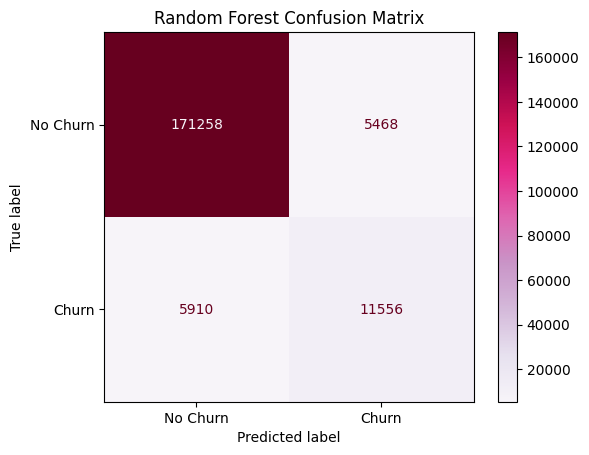

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="PuRd")
plt.title("Random Forest Confusion Matrix")
plt.show()

**ROC Curve Plot**

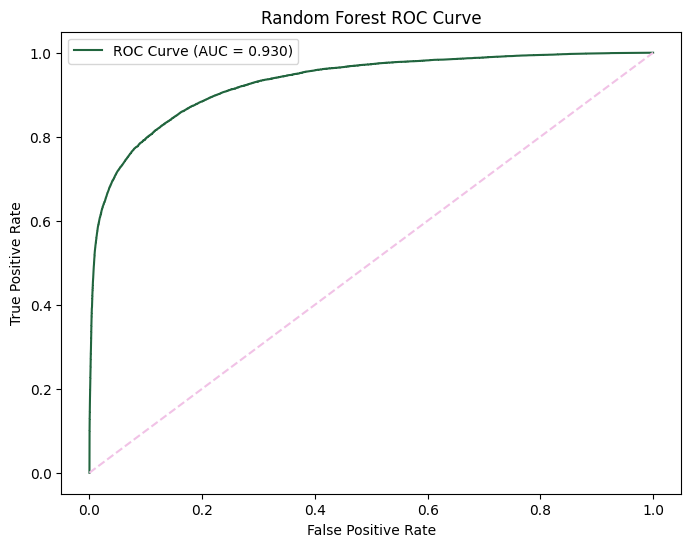

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#21653e", label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="#f1c2e6")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

**Top 15 Feature Importances Plot**

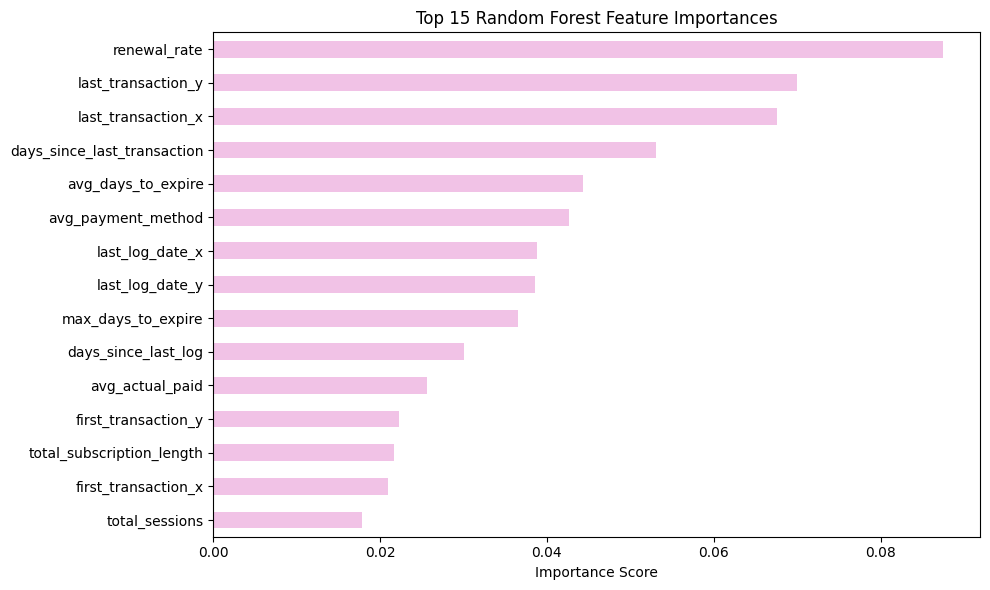

In [21]:
import matplotlib.pyplot as plt

top15 = feature_imp.sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind="barh", color="#f1c2e6")
plt.xlabel("Importance Score")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# Insights

The Random Forest model shows that a small number of features dominate the prediction process, with most variables contributing little to the overall model performance. There is a clear drop-off in importance after the top features, indicating that the model relies heavily on a limited set of key predictors.

The model captures complex, nonlinear relationships and interactions between variables, allowing it to identify patterns that simpler models may miss. Despite this flexibility, its predictions are still driven primarily by the most influential features.
